# Import Library

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
import shutil
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from skimage.metrics import structural_similarity as ssim

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

## 2 A

### Check Dataset

In [2]:
base_path = '../overhead'  
CLASSES = ['oil_gas_field', 'stadium']

for split in ['training', 'testing']:
    print(f"\n {split}/")
    total = 0
    for class_name in CLASSES:
        class_path = os.path.join(base_path, split, class_name)
        count = len(os.listdir(class_path))
        total += count
        print(f"   {class_name}: {count} images")
    print(f"   TOTAL: {total} images")


 training/
   oil_gas_field: 888 images
   stadium: 843 images
   TOTAL: 1731 images

 testing/
   oil_gas_field: 110 images
   stadium: 105 images
   TOTAL: 215 images


### EDA

In [3]:

IMAGE_SIZE = 28
BASE_PATH  = '../overhead'

X_raw, y_raw = [], []

for label, cls in enumerate(['oil_gas_field', 'stadium']):
    for split in ['training', 'testing']:
        folder = os.path.join(BASE_PATH, split, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                img = Image.open(os.path.join(folder, fname)).convert('L')
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
                X_raw.append(np.array(img, dtype='float32'))
                y_raw.append(label)

X_raw = np.array(X_raw).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)
y_raw = np.array(y_raw)

print(f"Total data   : {X_raw.shape[0]}")
print(f"Oil Gas Field: {np.sum(y_raw == 0)}")
print(f"Stadium      : {np.sum(y_raw == 1)}")

Total data   : 1946
Oil Gas Field: 998
Stadium      : 948


### Average image per kelas

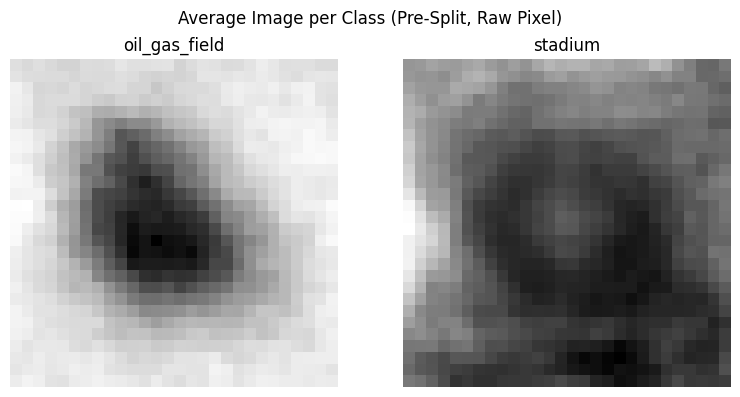

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for class_idx, cls in enumerate(['oil_gas_field', 'stadium']):
    avg_img = X_raw[y_raw == class_idx].mean(axis=0).squeeze()
    axes[class_idx].imshow(avg_img, cmap='gray')
    axes[class_idx].set_title(cls)
    axes[class_idx].axis('off')
plt.suptitle('Average Image per Class (Pre-Split, Raw Pixel)')
plt.tight_layout()
plt.show()

Rata-rata gambar per kelas menunjukkan pola visual yang berbeda antara Oil Gas Field dan Stadium. Oil Gas Field memperlihatkan objek gelap di tengah dengan latar terang, sedangkan Stadium cenderung sebaliknya dengan bagian tepi lebih terang.

### Histogram distribusi pixel

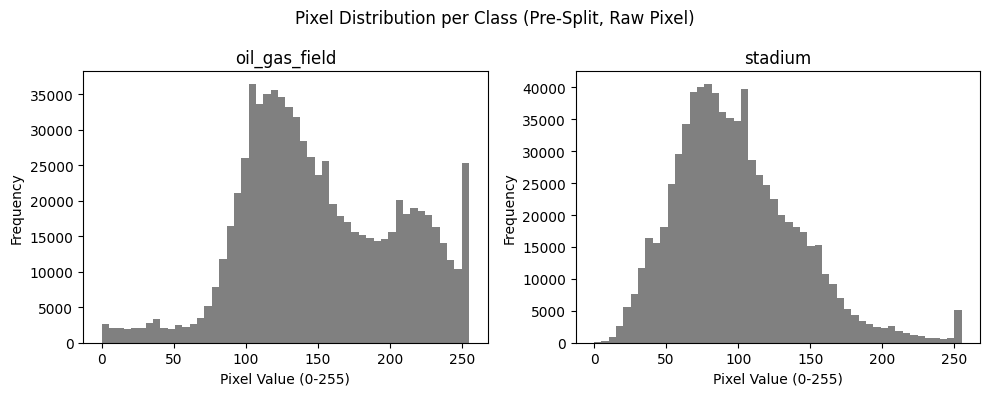

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for class_idx, cls in enumerate(['oil_gas_field', 'stadium']):
    pixels = X_raw[y_raw == class_idx].flatten()
    axes[class_idx].hist(pixels, bins=50, color='gray')
    axes[class_idx].set_title(cls)
    axes[class_idx].set_xlabel('Pixel Value (0-255)')
    axes[class_idx].set_ylabel('Frequency')
plt.suptitle('Pixel Distribution per Class (Pre-Split, Raw Pixel)')
plt.tight_layout()
plt.show()

Distribusi piksel Oil Gas Field berbentuk bimodal dengan puncak di sekitar nilai 100 dan 150, menandakan variasi tekstur yang cukup tinggi. Stadium menunjukkan distribusi yang lebih terpusat di nilai rendah hingga menengah, konsisten dengan karakteristik gambar yang secara rata-rata lebih gelap.

### Statistic for each class

In [6]:
for class_idx, cls in enumerate(['oil_gas_field', 'stadium']):
    pixels = X_raw[y_raw == class_idx].flatten()
    print(f"\n{cls}:")
    print(f"  mean={pixels.mean():.2f}, std={pixels.std():.2f}")
    print(f"  min={pixels.min():.0f}, max={pixels.max():.0f}")


oil_gas_field:
  mean=151.48, std=53.91
  min=0, max=255

stadium:
  mean=98.70, std=42.47
  min=0, max=255


Oil Gas Field memiliki rata-rata nilai piksel 151.48 dengan standar deviasi 53.91, lebih terang dibanding Stadium yang rata-ratanya hanya 98.70. Perbedaan ini menunjukkan bahwa gambar Oil Gas Field cenderung memiliki latar belakang lebih terang, sementara Stadium lebih gelap secara keseluruhan.


### Resplit Dataset

In [3]:
SEED = 42
BASE_PATH   = '../overhead'
OUTPUT_PATH = '.'
CLASSES     = ['oil_gas_field', 'stadium']

In [4]:
for class_name in CLASSES:
   
    all_images = []
    for split_folder in ['training', 'testing']:
        folder = os.path.join(BASE_PATH, split_folder, class_name)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                all_images.append(os.path.join(folder, fname))
    
    print(f"\n{class_name}: {len(all_images)} total images")
    

    train_imgs, temp_imgs = train_test_split(all_images, test_size=0.20, random_state=SEED)
    val_imgs, test_imgs   = train_test_split(temp_imgs,  test_size=0.50, random_state=SEED)
    
    print(f"  Train : {len(train_imgs)}")
    print(f"  Val   : {len(val_imgs)}")
    print(f"  Test  : {len(test_imgs)}")
    
 
    for split_name, img_paths in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        out_folder = os.path.join(OUTPUT_PATH, class_name, split_name)
        os.makedirs(out_folder, exist_ok=True)
        for img_path in img_paths:
            shutil.copy(img_path, os.path.join(out_folder, os.path.basename(img_path)))


oil_gas_field: 998 total images
  Train : 798
  Val   : 100
  Test  : 100

stadium: 948 total images
  Train : 758
  Val   : 95
  Test  : 95


Folder training dan testing dari dataset asli digabung terlebih dahulu per kelas, lalu dibagi ulang secara acak menjadi 80% train, 10% validasi, dan 10% test menggunakan strategi dua tahap split. Hasilnya adalah Oil Gas Field dengan 798/100/100 gambar dan Stadium dengan 758/95/95 gambar, lalu masing-masing disalin ke folder terpisah sesuai pembagiannya.

### Load and Scale Data

In [7]:

IMG_SIZE   = (28, 28)
BATCH_SIZE = 32

#### oil_gas_field

In [8]:
train_ogf = tf.keras.utils.image_dataset_from_directory(
    'oil_gas_field/train',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed=42
)
val_ogf = tf.keras.utils.image_dataset_from_directory(
    'oil_gas_field/val',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)
test_ogf = tf.keras.utils.image_dataset_from_directory(
    'oil_gas_field/test',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)


Found 798 files belonging to 1 classes.
Found 100 files belonging to 1 classes.
Found 100 files belonging to 1 classes.


In [9]:
train_ogf = train_ogf.map(lambda x: x / 255.0)
val_ogf   = val_ogf.map(lambda x: x / 255.0)
test_ogf  = test_ogf.map(lambda x: x / 255.0)

In [10]:
train_ogf = train_ogf.map(lambda x: (x, x))
val_ogf   = val_ogf.map(lambda x: (x, x))
test_ogf  = test_ogf.map(lambda x: (x, x))

#### stadium

In [11]:
train_std = tf.keras.utils.image_dataset_from_directory(
    'stadium/train',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed=42
)
val_std = tf.keras.utils.image_dataset_from_directory(
    'stadium/val',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)
test_std = tf.keras.utils.image_dataset_from_directory(
    'stadium/test',
    labels=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)


Found 758 files belonging to 1 classes.
Found 95 files belonging to 1 classes.
Found 95 files belonging to 1 classes.


Dataset dimuat dari folder hasil resplit dalam mode grayscale tanpa label, dinormalisasi ke rentang 0 hingga 1, lalu diubah menjadi pasangan (X, X) karena autoencoder belajar merekonstruksi inputnya sendiri.

In [12]:
train_std = train_std.map(lambda x: x / 255.0)
val_std   = val_std.map(lambda x: x / 255.0)
test_std  = test_std.map(lambda x: x / 255.0)

In [13]:
train_std = train_std.map(lambda x: (x, x))
val_std   = val_std.map(lambda x: (x, x))
test_std  = test_std.map(lambda x: (x, x))

Dataset dimuat dari folder hasil resplit dalam mode grayscale tanpa label, dinormalisasi ke rentang 0 hingga 1, lalu diubah menjadi pasangan (X, X) karena autoencoder belajar merekonstruksi inputnya sendiri.

### Visualization Training Sample from Oil Gas Field and Stadium

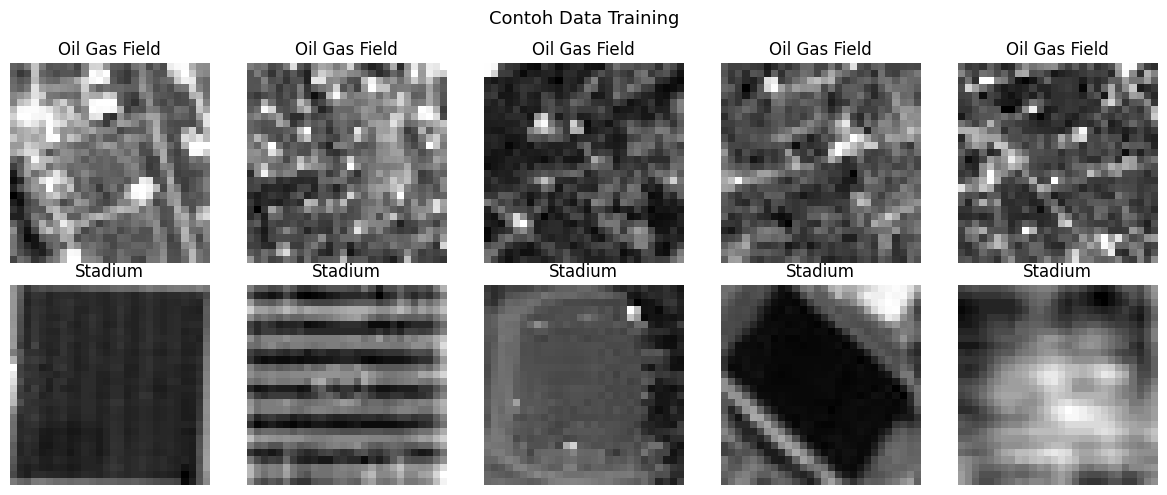

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

sample_ogf = next(iter(train_ogf)) 
for i in range(5):
    axes[0, i].imshow(sample_ogf[0][i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Oil Gas Field')
    axes[0, i].axis('off')


sample_std = next(iter(train_std))  
for i in range(5):
    axes[1, i].imshow(sample_std[0][i].numpy().squeeze(), cmap='gray') 
    axes[1, i].set_title('Stadium')
    axes[1, i].axis('off')

plt.suptitle('Contoh Data Training', fontsize=13)
plt.tight_layout()
plt.show()

Visualisasi menampilkan lima contoh gambar acak dari masing-masing kelas pada training set untuk memverifikasi bahwa data berhasil dimuat dengan benar. Terlihat bahwa gambar Oil Gas Field memiliki tekstur yang lebih beragam dan noisy, sementara Stadium cenderung memiliki pola garis atau bentuk geometris yang lebih terstruktur.



## 2 B

### oil_gas_field baseline model

In [19]:
ae_ogf = Sequential([
    # ENCODER
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(), 
    layers.Dense(128, activation='relu'),

    # DECODER
    layers.Dense(6272), 
    layers.Reshape((14, 14, 32)), 
    layers.UpSampling2D((2,2)), 
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),  
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same') 
], name='autoencoder_oil_gas_field')

ae_ogf.compile(optimizer='adam', loss='mse')
ae_ogf.summary()

Model: "autoencoder_oil_gas_field"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 6272)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               802944    
                                                                 
 dense_3 (Dense)             (None, 6272)              809088    
                                                                 
 reshape_1 (Reshape)         (None, 14, 14, 32)        0         
                                         

Arsitektur baseline mengikuti diagram yang diberikan, dengan encoder yang mengompresi gambar 28x28 menjadi representasi laten berukuran 128 melalui Conv2D, MaxPooling, Flatten, dan Dense layer. Decoder kemudian merekonstruksi kembali ke dimensi aslinya menggunakan Dense, Reshape, UpSampling, dan dua Conv2D layer dengan aktivasi terakhir sigmoid.

In [20]:
early_stop_ogf = EarlyStopping(
    monitor='val_loss',
    patience=10,           
    restore_best_weights=True,
    verbose=1
)

In [21]:
checkpoint_ogf = ModelCheckpoint(
    filepath='models/baseline_ogf.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

Model dikompilasi dengan optimizer Adam dan loss MSE. EarlyStopping dengan patience 10 menghentikan training saat val_loss tidak membaik dan mengembalikan bobot terbaik secara otomatis, sementara ModelCheckpoint menyimpan model terbaik ke disk selama training berlangsung.

In [22]:
with tf.device('/GPU:0'):
    history_ogf = ae_ogf.fit(
        train_ogf,
        epochs=200,
        validation_data=val_ogf,
        callbacks=[early_stop_ogf, checkpoint_ogf],
        verbose=1
    )

Epoch 1/200
25/25 [==============================] - ETA: 0s - loss: 0.0425
Epoch 1: val_loss improved from inf to 0.03750, saving model to models\baseline_ogf.keras
25/25 [==============================] - 1s 29ms/step - loss: 0.0425 - val_loss: 0.0375
Epoch 2/200
17/25 [===================>..........] - ETA: 0s - loss: 0.0365
Epoch 2: val_loss improved from 0.03750 to 0.03290, saving model to models\baseline_ogf.keras
25/25 [==============================] - 0s 13ms/step - loss: 0.0357 - val_loss: 0.0329
Epoch 3/200
16/25 [==================>...........] - ETA: 0s - loss: 0.0325
Epoch 3: val_loss improved from 0.03290 to 0.03171, saving model to models\baseline_ogf.keras
25/25 [==============================] - 0s 13ms/step - loss: 0.0323 - val_loss: 0.0317
Epoch 4/200
16/25 [==================>...........] - ETA: 0s - loss: 0.0313
Epoch 4: val_loss improved from 0.03171 to 0.02996, saving model to models\baseline_ogf.keras
25/25 [==============================] - 0s 12ms/step - loss

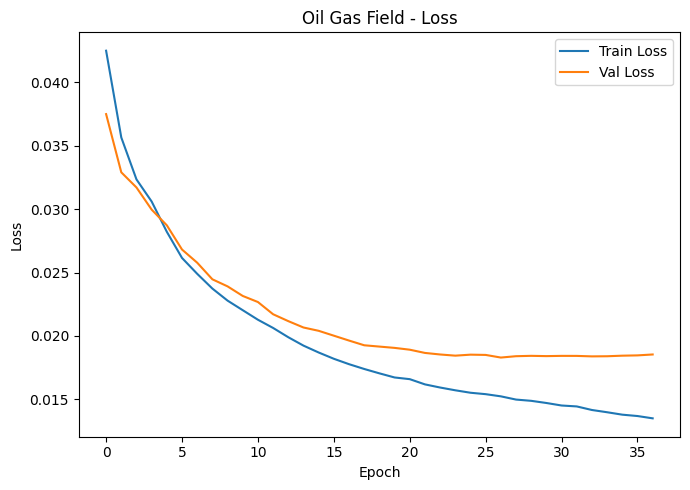

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(history_ogf.history['loss'], label='Train Loss')
plt.plot(history_ogf.history['val_loss'], label='Val Loss')
plt.title('Oil Gas Field - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Kedua loss turun secara konsisten di awal training, namun val loss mulai plateau di sekitar epoch 25 sementara train loss terus menurun, membentuk gap yang mengindikasikan mild overfitting. Meski demikian, val loss tidak naik sehingga overfitting yang terjadi masih dalam batas wajar dan bukan kategori parah. Early stopping menghentikan training di epoch ke-37 karena val loss tidak membaik selama 10 epoch berturut-turut, dan bobot terbaik dikembalikan otomatis melalui restore_best_weights.

### stadium baseline model

In [24]:
ae_std = Sequential([
    # ENCODER
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'), # 28x28x32
    layers.MaxPooling2D((2,2)),  # 14x14x32
    layers.Flatten(), # 6272
    layers.Dense(128, activation='relu'), # latent 128

    # DECODER
    layers.Dense(6272), # 6272
    layers.Reshape((14, 14, 32)),  # 14x14x32
    layers.UpSampling2D((2,2)),  # 28x28x32
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),  # 28x28x32
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same') # 28x28x1
], name='autoencoder_stadium')

ae_std.compile(optimizer='adam', loss='mse')
ae_std.summary()

Model: "autoencoder_stadium"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 6272)              0         
                                                                 
 dense_4 (Dense)             (None, 128)               802944    
                                                                 
 dense_5 (Dense)             (None, 6272)              809088    
                                                                 
 reshape_2 (Reshape)         (None, 14, 14, 32)        0         
                                               

Arsitektur baseline mengikuti diagram yang diberikan, dengan encoder yang mengompresi gambar 28x28 menjadi representasi laten berukuran 128 melalui Conv2D, MaxPooling, Flatten, dan Dense layer. Decoder kemudian merekonstruksi kembali ke dimensi aslinya menggunakan Dense, Reshape, UpSampling, dan dua Conv2D layer dengan aktivasi terakhir sigmoid.

In [25]:
early_stop_std = EarlyStopping(
    monitor='val_loss',
    patience=10,         
    restore_best_weights=True,
    verbose=1
)


In [26]:
checkpoint_std = ModelCheckpoint(filepath='models/baseline_std.keras', monitor='val_loss', save_best_only=True, verbose=1)


Model dikompilasi dengan optimizer Adam dan loss MSE. EarlyStopping dengan patience 10 menghentikan training saat val_loss tidak membaik dan mengembalikan bobot terbaik secara otomatis, sementara ModelCheckpoint menyimpan model terbaik ke disk selama training berlangsung.

In [27]:
with tf.device('/GPU:0'):
    history_std = ae_std.fit(
        train_std,
        epochs=200,
        validation_data=val_std,
        callbacks=[early_stop_std, checkpoint_std],
        verbose=1
    )

Epoch 1/200
24/24 [==============================] - ETA: 0s - loss: 0.0338
Epoch 1: val_loss improved from inf to 0.02882, saving model to models\baseline_std.keras
24/24 [==============================] - 1s 41ms/step - loss: 0.0338 - val_loss: 0.0288
Epoch 2/200
15/24 [=================>............] - ETA: 0s - loss: 0.0237
Epoch 2: val_loss improved from 0.02882 to 0.01420, saving model to models\baseline_std.keras
24/24 [==============================] - 0s 13ms/step - loss: 0.0199 - val_loss: 0.0142
Epoch 3/200
24/24 [==============================] - ETA: 0s - loss: 0.0108
Epoch 3: val_loss improved from 0.01420 to 0.01206, saving model to models\baseline_std.keras
24/24 [==============================] - 0s 13ms/step - loss: 0.0108 - val_loss: 0.0121
Epoch 4/200
15/24 [=================>............] - ETA: 0s - loss: 0.0097
Epoch 4: val_loss improved from 0.01206 to 0.01033, saving model to models\baseline_std.keras
24/24 [==============================] - 0s 13ms/step - loss

### Training and Validation Loss

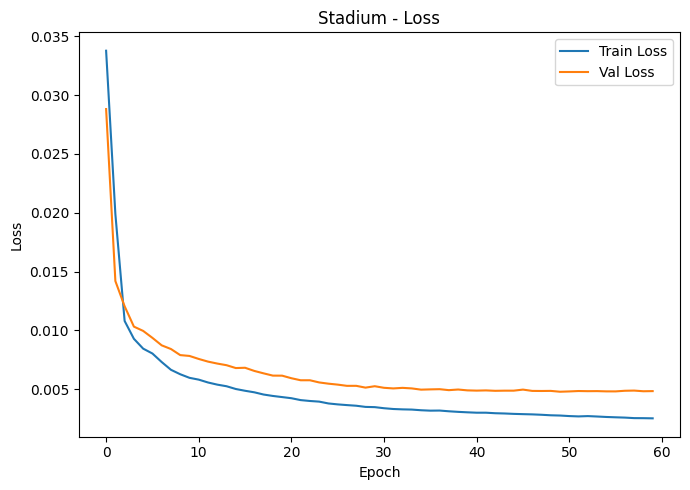

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(history_std.history['loss'], label='Train Loss')
plt.plot(history_std.history['val_loss'], label='Val Loss')
plt.title('Stadium - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Kurva Stadium menunjukkan hasil yang lebih baik dibanding Oil Gas Field, dengan train loss dan val loss yang turun beriringan secara konsisten hingga epoch ke-60. Gap antara keduanya sangat kecil di sekitar 0.003, menandakan overfitting yang minimal dan model berhasil melakukan generalisasi dengan baik pada data validasi. Early stopping menghentikan training di epoch ke-60 karena val loss tidak membaik selama 10 epoch berturut-turut, dengan bobot terbaik dikembalikan otomatis melalui restore_best_weights

### Evaluation Test Set

In [29]:

def evaluate_ssim(model, test_ds, name):
    ssim_scores = []
    
    for batch in test_ds:
        X_batch = batch[0] 
        reconstructed = model.predict(X_batch, verbose=0)
        
        for orig, recon in zip(X_batch.numpy(), reconstructed):
            score = ssim(
                orig.squeeze(),
                recon.squeeze(),
                data_range=1.0
            )
            ssim_scores.append(score)
    
    mean_ssim = np.mean(ssim_scores)
    print(f"[{name}] Mean SSIM: {mean_ssim:.4f}")
    return mean_ssim



Evaluasi dilakukan dengan menghitung Structural Similarity Index (SSIM) antara gambar asli dan hasil rekonstruksi pada seluruh batch di test set. Nilai SSIM berkisar antara 0 hingga 1, di mana nilai yang mendekati 1 menunjukkan rekonstruksi yang semakin mirip dengan gambar aslinya secara struktural, bukan sekadar pixel-wise error seperti MSE.



#### oil_gas_field

In [30]:
ae_ogf = load_model('models/baseline_ogf.keras')

In [31]:
ssim_ogf = evaluate_ssim(ae_ogf, test_ogf, "Oil Gas Field")

[Oil Gas Field] Mean SSIM: 0.3973


1. Model baseline Oil Gas Field mendapat SSIM  0.3973, nilai ini tergolong rendah karena SSIM di bawah 0.5 menunjukkan rekonstruksi yang belum cukup baik secara struktural.

2. Tekstur Oil Gas Field sangat kompleks dan variatif, terbukti dari distribusi piksel yang bimodal dan standar deviasi yang tinggi (53.91), sehingga informasinya sulit dikompresi secara optimal ke representasi 128 dimensi tanpa kehilangan detail penting.

3. Mild overfitting terlihat dari val loss yang plateau lebih awal dibanding train loss, menandakan model mulai menghafal data training dan kurang generalisasi ke test set.

#### Stadium

In [32]:
ae_std = load_model('models/baseline_std.keras')

In [33]:

ssim_std = evaluate_ssim(ae_std, test_std, "Stadium")

[Stadium] Mean SSIM: 0.6613


1. Model baseline Stadium mendapat SSIM  0.6613, nilai ini tergolong baik karena mendekati 0.7 yang menunjukkan rekonstruksi sudah cukup merepresentasikan struktur visual gambar aslinya.

2. Hasil ini lebih baik dibanding Oil Gas Field karena gambar Stadium memiliki pola yang lebih seragam dan standar deviasi piksel lebih rendah (42.47), sehingga lebih mudah dikompresi ke 128 dimensi tanpa kehilangan banyak informasi.

3. Kurva loss menunjukkan sedikit overfitting dengan gap kecil antara train dan val loss di bagian akhir training, namun masih dalam batas wajar dan tidak mempengaruhi kemampuan generalisasi model secara signifikan.

### Visualization

#### oil_gas_field

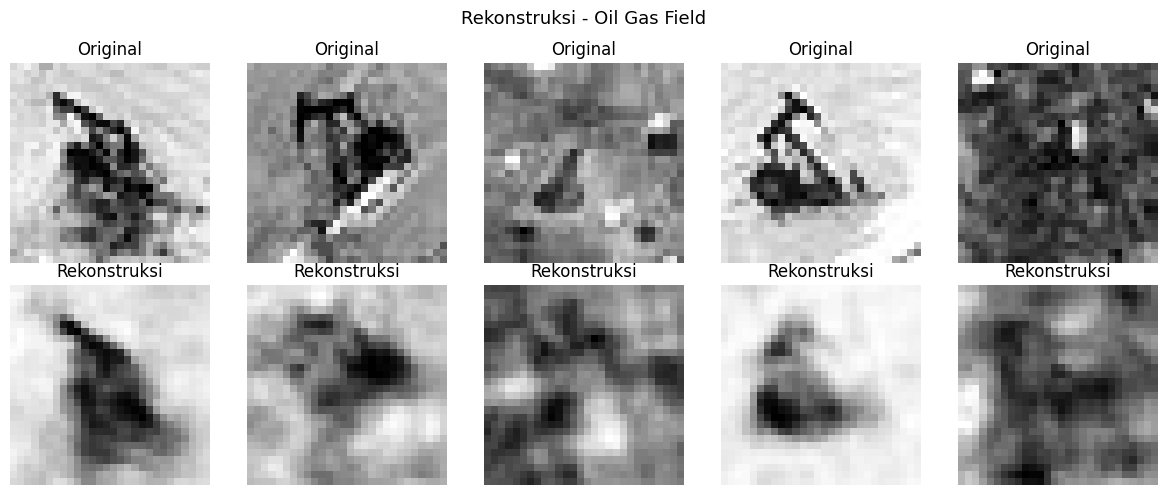

In [34]:
batch = next(iter(test_ogf))
X_batch = batch[0]
reconstructed = ae_ogf.predict(X_batch, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Rekonstruksi')
    axes[1, i].axis('off')
plt.suptitle('Rekonstruksi - Oil Gas Field', fontsize=13)
plt.tight_layout()
plt.show()

Hasil rekonstruksi Oil Gas Field menangkap bentuk dan pola utama objek dengan cukup baik, namun detail halus seperti tekstur latar belakang dan tepi objek terlihat lebih blur dibanding gambar aslinya. Ini konsisten dengan SSIM  0.3973 yang menunjukkan model baseline belum optimal dalam mempertahankan detail struktural gambar yang kompleks.

#### stadium

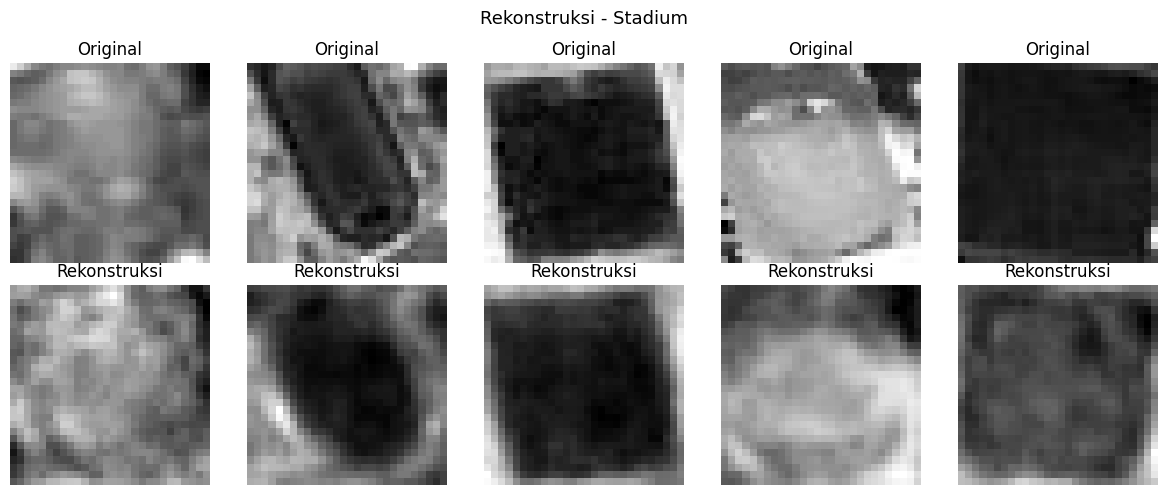

In [35]:
batch = next(iter(test_std))
X_batch = batch[0]
reconstructed = ae_std.predict(X_batch, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Rekonstruksi')
    axes[1, i].axis('off')
plt.suptitle('Rekonstruksi - Stadium', fontsize=13)
plt.tight_layout()
plt.show()

Rekonstruksi Stadium terlihat lebih baik dibanding Oil Gas Field, dengan bentuk umum objek yang masih dapat dikenali meski beberapa detail halus hilang akibat proses kompresi ke 128 dimensi. Hasil ini sejalan dengan SSIM  0.6613 yang menunjukkan model baseline mampu merekonstruksi gambar Stadium dengan kualitas yang lebih baik berkat karakteristik visualnya yang lebih seragam.

## 2 C

#### loss function

In [116]:
def ssim_mse_loss(alpha):
    def loss(y_true, y_pred):
        mse_term  = tf.reduce_mean(tf.square(y_true - y_pred))
        ssim_term = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
        return mse_term + alpha * (1.0 - ssim_term)
    return loss

1. Loss function modified menggabungkan MSE dan SSIM dengan formula `MSE + alpha * (1 - SSIM)`, sehingga model tidak hanya mengoptimalkan pixel-wise error tapi juga kualitas struktural gambar rekonstruksi.

2. Nilai alpha mengontrol seberapa besar pengaruh SSIM dalam total loss, dengan Oil Gas Field menggunakan alpha 0.5 dan Stadium menggunakan alpha 1

### oil_gas_field modified model

In [117]:
ae_ogf_mod3 = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(6272, activation='relu'),
    layers.Reshape((14, 14, 32)),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
], name='autoencoder_ogf_mod3')

ae_ogf_mod3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=ssim_mse_loss(alpha=0.5)
)

1. BatchNormalization ditambahkan setelah Conv2D di encoder dan decoder untuk menstabilkan distribusi aktivasi antar layer, sehingga training lebih stabil dan model lebih tahan terhadap overfitting yang terjadi pada baseline.

2. Learning rate dikecilkan dari default Adam (0.001) menjadi 0.0005 agar model melakukan update bobot lebih hati-hati, mengurangi risiko melewati titik optimal terutama saat val loss sudah mendekati plateau.

3. Loss function diganti dari MSE murni menjadi kombinasi MSE dan SSIM dengan alpha 0.5, sehingga model secara langsung dioptimalkan untuk menghasilkan rekonstruksi yang lebih baik secara struktural, bukan hanya pixel-wise error.

In [ ]:
early_stop_ogf_mod = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
checkpoint_ogf_mod = ModelCheckpoint(
    filepath='models/modified_ogf.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
reduce_lr_ogf_mod = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

1. EarlyStopping menghentikan training secara otomatis saat val loss tidak membaik selama 10 epoch berturut-turut dan mengembalikan bobot terbaik melalui `restore_best_weights`.

2. ModelCheckpoint menyimpan model ke disk setiap kali val loss mencapai nilai terbaik selama training berlangsung, sehingga model optimal tidak hilang meski training dilanjutkan.

3. ReduceLROnPlateau memangkas learning rate sebesar 0.5 setiap kali val loss stagnan selama 4 epoch, membantu model melakukan fine-tuning lebih halus saat mendekati titik konvergensi.

In [121]:
with tf.device('/GPU:0'):
    history_ogf_mod = ae_ogf_mod3.fit(
        train_ogf,
        epochs=200,
        validation_data=val_ogf,
        callbacks=[early_stop_ogf_mod, checkpoint_ogf_mod,reduce_lr_ogf_mod],
        verbose=1
    )

Epoch 1/200
25/25 [==============================] - ETA: 0s - loss: 0.4897
Epoch 1: val_loss improved from inf to 0.49987, saving model to models\modified_ogf.keras
25/25 [==============================] - 2s 37ms/step - loss: 0.4897 - val_loss: 0.4999 - lr: 5.0000e-04
Epoch 2/200
19/25 [=====================>........] - ETA: 0s - loss: 0.3745
Epoch 2: val_loss improved from 0.49987 to 0.49120, saving model to models\modified_ogf.keras
25/25 [==============================] - 0s 16ms/step - loss: 0.3673 - val_loss: 0.4912 - lr: 5.0000e-04
Epoch 3/200
23/25 [==========================>...] - ETA: 0s - loss: 0.2997
Epoch 3: val_loss improved from 0.49120 to 0.48329, saving model to models\modified_ogf.keras
25/25 [==============================] - 1s 16ms/step - loss: 0.2994 - val_loss: 0.4833 - lr: 5.0000e-04
Epoch 4/200
24/25 [===========================>..] - ETA: 0s - loss: 0.2593
Epoch 4: val_loss improved from 0.48329 to 0.47686, saving model to models\modified_ogf.keras
25/25 [==

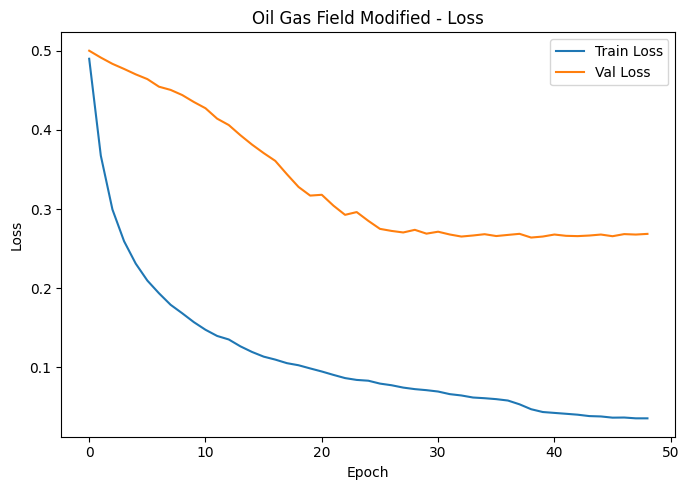

In [122]:
plt.figure(figsize=(7, 5))
plt.plot(history_ogf_mod.history['loss'], label='Train Loss')
plt.plot(history_ogf_mod.history['val_loss'], label='Val Loss')
plt.title('Oil Gas Field Modified - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

1. Kurva modified Oil Gas Field menunjukkan overfitting yang lebih terlihat dibanding baseline dengan gap train dan val loss yang cukup besar, namun sebagian disebabkan perbedaan skala loss karena modified menggunakan kombinasi MSE dan SSIM yang nilainya lebih besar dari pure MSE.

2. Val loss tetap turun dan tidak naik selama training, sehingga meski overfit model masih belajar dengan benar dan early stopping menghentikan training di epoch ke-49.

3. Evaluasi yang lebih relevan tetap mengacu pada SSIM score di test set karena perbedaan loss function membuat perbandingan nilai loss secara langsung tidak apple-to-apple.

### stadium modified model

In [123]:
# STD - alpha=1.0
ae_std_mod3 = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(6272, activation='relu'),
    layers.Reshape((14, 14, 32)),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
], name='autoencoder_std_mod3')

ae_std_mod3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=ssim_mse_loss(alpha=1.0)
)


1. BatchNormalization ditambahkan setelah Conv2D di encoder dan decoder untuk menstabilkan distribusi aktivasi, mengurangi internal covariate shift sehingga training lebih konsisten dan stabil.

2. Learning rate dikecilkan dari default Adam (0.001) menjadi 0.0005 agar update bobot lebih hati-hati dan tidak melewati titik optimal, terutama saat loss sudah mendekati konvergensi.

3. Loss function diganti menjadi kombinasi MSE dan SSIM dengan alpha 1.0 (lebih besar dari Oil Gas Field yang 0.5), karena Stadium memiliki struktur visual yang lebih seragam sehingga model bisa lebih agresif mengoptimalkan kualitas struktural tanpa kehilangan stabilitas training.

In [ ]:
early_stop_std_mod = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
checkpoint_std_mod = ModelCheckpoint(
    filepath='models/modified_std.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
reduce_lr_std_mod = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

1. EarlyStopping menghentikan training secara otomatis saat val loss tidak membaik selama 10 epoch berturut-turut dan mengembalikan bobot terbaik melalui `restore_best_weights`.

2. ModelCheckpoint menyimpan model ke disk setiap kali val loss mencapai nilai terbaik selama training berlangsung, sehingga model optimal tidak hilang meski training dilanjutkan.

3. ReduceLROnPlateau memangkas learning rate sebesar 0.5 setiap kali val loss stagnan selama 4 epoch, membantu model melakukan fine-tuning lebih halus saat mendekati titik konvergensi.

In [127]:
with tf.device('/GPU:0'):
    history_std_mod = ae_std_mod3.fit(
        train_std,
        epochs=200,
        validation_data=val_std,
        callbacks=[early_stop_std_mod, checkpoint_std_mod,reduce_lr_std_mod],
        verbose=1
    )

Epoch 1/200
20/24 [========================>.....] - ETA: 0s - loss: 0.6539
Epoch 1: val_loss improved from inf to 0.59591, saving model to models\modified_std.keras
24/24 [==============================] - 2s 25ms/step - loss: 0.6332 - val_loss: 0.5959 - lr: 5.0000e-04
Epoch 2/200
19/24 [======================>.......] - ETA: 0s - loss: 0.4684
Epoch 2: val_loss improved from 0.59591 to 0.49891, saving model to models\modified_std.keras
24/24 [==============================] - 0s 16ms/step - loss: 0.4663 - val_loss: 0.4989 - lr: 5.0000e-04
Epoch 3/200
18/24 [=====================>........] - ETA: 0s - loss: 0.4318
Epoch 3: val_loss improved from 0.49891 to 0.46519, saving model to models\modified_std.keras
24/24 [==============================] - 0s 16ms/step - loss: 0.4286 - val_loss: 0.4652 - lr: 5.0000e-04
Epoch 4/200
21/24 [=========================>....] - ETA: 0s - loss: 0.3948
Epoch 4: val_loss improved from 0.46519 to 0.45689, saving model to models\modified_std.keras
24/24 [==

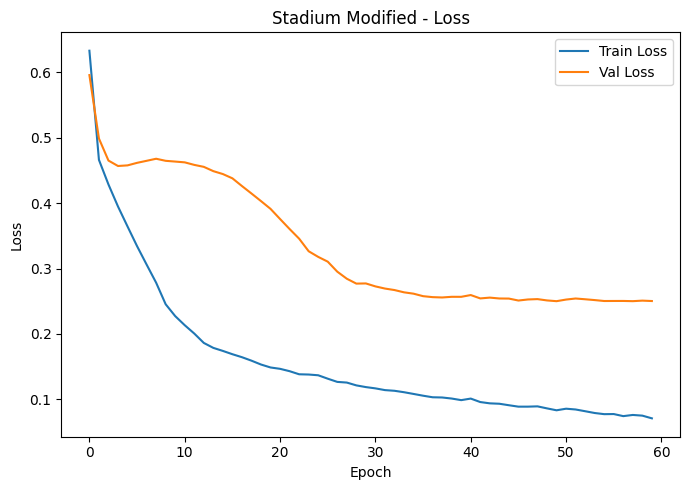

In [128]:
plt.figure(figsize=(7, 5))
plt.plot(history_std_mod.history['loss'], label='Train Loss')
plt.plot(history_std_mod.history['val_loss'], label='Val Loss')
plt.title('Stadium Modified - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

1. Kurva Stadium modified menunjukkan overfitting yang terlihat dari gap besar antara train loss dan val loss sepanjang training, serupa dengan Oil Gas Field modified, yang sebagian disebabkan perbedaan skala loss dari kombinasi MSE dan SSIM.

2. Meski demikian, val loss tetap turun secara konsisten dari 0.6 hingga plateau di sekitar 0.25 tanpa naik kembali, sehingga overfitting yang terjadi masih dalam batas wajar dan early stopping menghentikan training di epoch ke-60.

3. Evaluasi yang relevan tetap mengacu pada SSIM score di test set karena nilai loss tidak bisa dibandingkan langsung dengan baseline yang menggunakan pure MSE.

### Evaluation Test Set

In [36]:
def ssim_mse_loss(alpha):
    def loss(y_true, y_pred):
        mse_term  = tf.reduce_mean(tf.square(y_true - y_pred))
        ssim_term = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
        return mse_term + alpha * (1.0 - ssim_term)
    return loss

In [37]:
ae_ogf_mod3 = load_model('models/modified_ogf.keras',
                          custom_objects={'loss': ssim_mse_loss(0.5)})

In [38]:
ssim_ogf_mod = evaluate_ssim(ae_ogf_mod3, test_ogf, "Oil Gas Field Modified")

[Oil Gas Field Modified] Mean SSIM: 0.4965


Model modified berhasil meningkatkan SSIM Oil Gas Field dari  0.3973 menjadi 0.4965, naik sebesar 0.0992. Peningkatan ini menunjukkan bahwa BatchNormalization dan custom SSIM+MSE loss dengan alpha 0.5 cukup efektif membantu model merekonstruksi tekstur kompleks Oil Gas Field yang sebelumnya menjadi kelemahan utama baseline.

In [39]:
ae_std_mod3 = load_model('models/modified_std.keras',
                          custom_objects={'loss': ssim_mse_loss(1.0)})

In [40]:
ssim_std_mod = evaluate_ssim(ae_std_mod3, test_std, "Stadium Modified")

[Stadium Modified] Mean SSIM: 0.7449


Model modified berhasil meningkatkan SSIM Stadium dari  0.6613 menjadi 0.7449, naik sebesar 0.0836. Nilai 0.7449 tergolong baik dan menunjukkan model sudah mampu merekonstruksi struktur visual gambar Stadium dengan cukup akurat meski dikompresi ke representasi 128 dimensi, dengan alpha 1.0 terbukti tepat untuk karakteristik gambar Stadium yang lebih seragam.

### Visualization

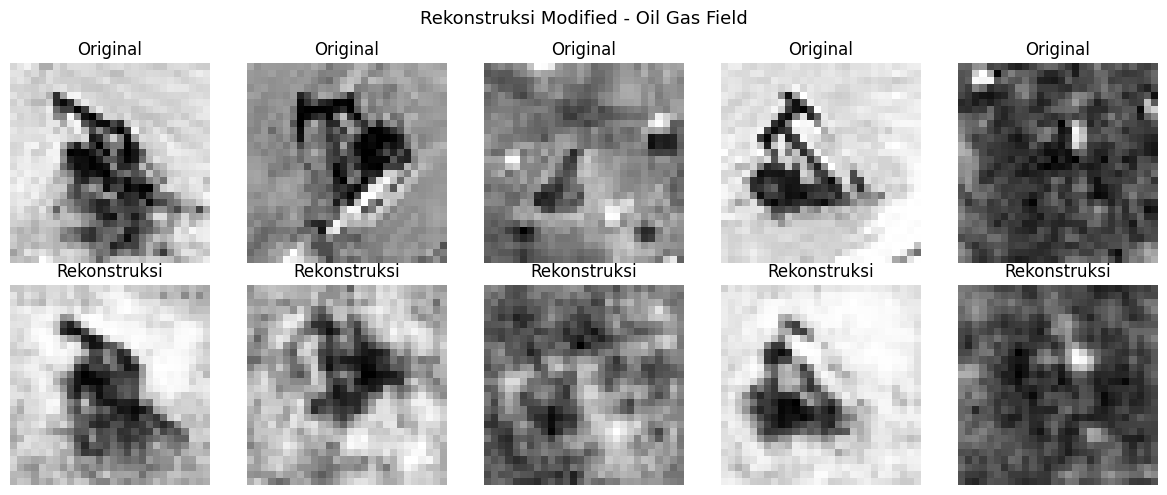

In [41]:
batch = next(iter(test_ogf))
X_batch = batch[0]
reconstructed = ae_ogf_mod3.predict(X_batch, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Rekonstruksi')
    axes[1, i].axis('off')
plt.suptitle('Rekonstruksi Modified - Oil Gas Field', fontsize=13)
plt.tight_layout()
plt.show()

Rekonstruksi modified Oil Gas Field terlihat lebih baik dibanding baseline, dengan bentuk objek utama yang lebih tajam dan detail struktural yang lebih terjaga seperti terlihat pada gambar pertama dan keempat. Peningkatan ini konsisten dengan kenaikan SSIM dari  0.3973 menjadi 0.4965, meski beberapa gambar dengan tekstur sangat kompleks masih menghasilkan rekonstruksi yang agak blur.

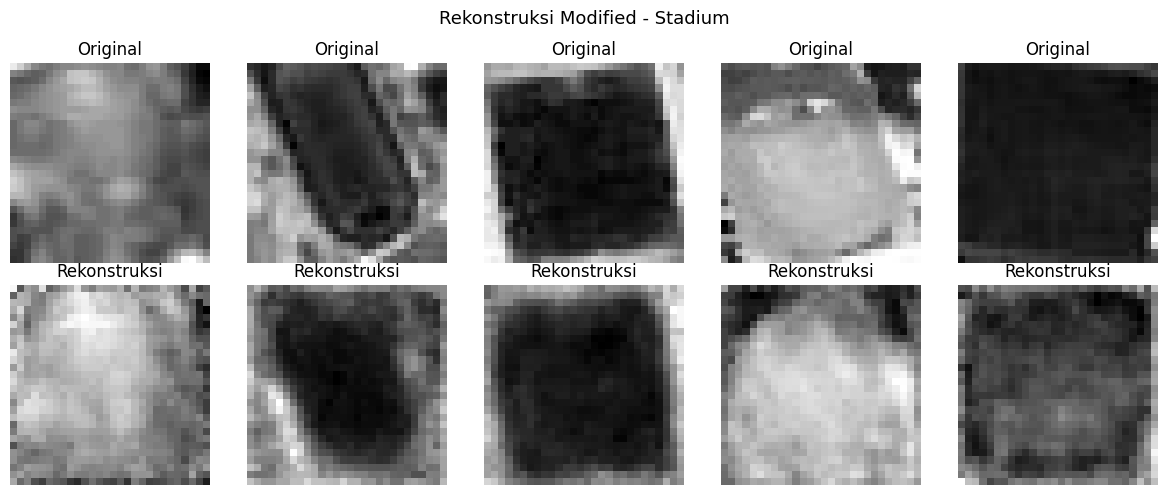

In [42]:
batch = next(iter(test_std))
X_batch = batch[0]
reconstructed = ae_std_mod3.predict(X_batch, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Rekonstruksi')
    axes[1, i].axis('off')
plt.suptitle('Rekonstruksi Modified - Stadium', fontsize=13)
plt.tight_layout()
plt.show()

Rekonstruksi modified Stadium berhasil mempertahankan bentuk umum dan distribusi intensitas gambar dengan cukup baik, terlihat dari pola gelap terang yang secara umum mengikuti gambar aslinya. Hasil ini sejalan dengan SSIM 0.7449, meski detail halus seperti tekstur permukaan masih sedikit hilang akibat proses kompresi ke 128 dimensi.

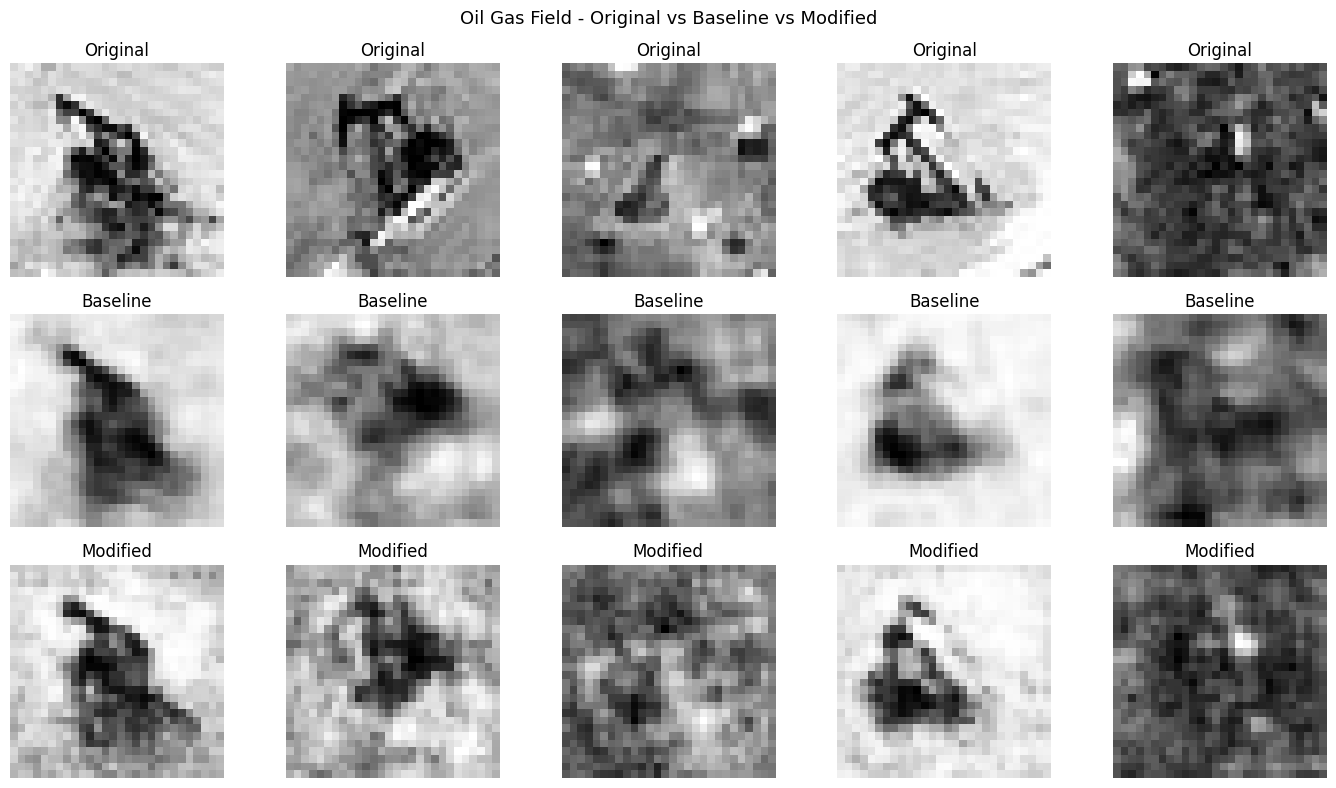

In [43]:
batch = next(iter(test_ogf))
X_batch = batch[0]

recon_baseline = ae_ogf.predict(X_batch, verbose=0)
recon_modified = ae_ogf_mod3.predict(X_batch, verbose=0)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_baseline[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Baseline')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_modified[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Modified')
    axes[2, i].axis('off')

plt.suptitle('Oil Gas Field - Original vs Baseline vs Modified', fontsize=13)
plt.tight_layout()
plt.show()

Perbandingan visual menunjukkan rekonstruksi modified Oil Gas Field secara konsisten lebih tajam dibanding baseline, dengan detail objek seperti struktur pipeline dan kontras gelap terang yang lebih mendekati gambar aslinya. Baseline cenderung menghasilkan rekonstruksi yang lebih blur dan kehilangan tepi objek, sementara modified berhasil mempertahankan struktur utama dengan lebih baik berkat optimasi SSIM langsung pada loss function.

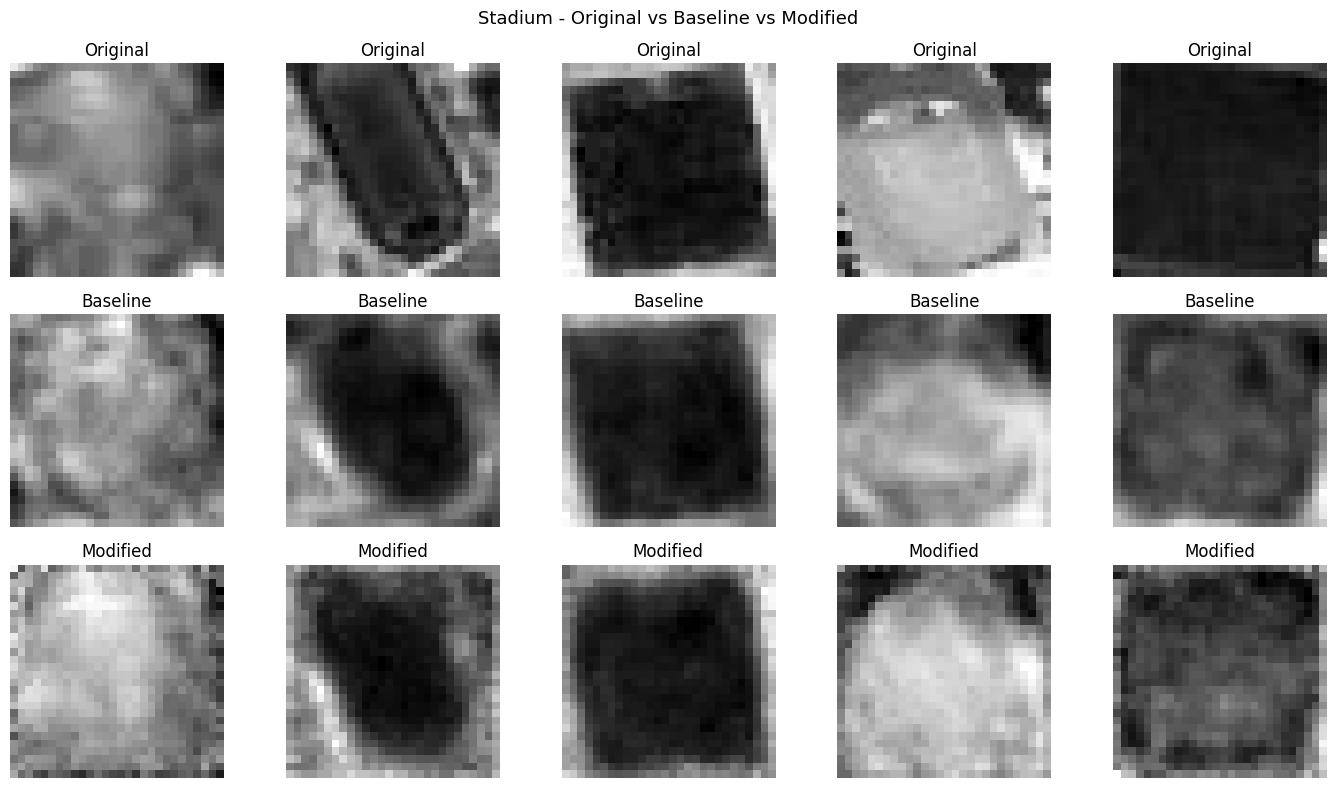

In [44]:
batch = next(iter(test_std))
X_batch = batch[0]

recon_baseline = ae_std.predict(X_batch, verbose=0)
recon_modified = ae_std_mod3.predict(X_batch, verbose=0)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i in range(5):
    axes[0, i].imshow(X_batch[i].numpy().squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_baseline[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Baseline')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_modified[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Modified')
    axes[2, i].axis('off')

plt.suptitle('Stadium - Original vs Baseline vs Modified', fontsize=13)
plt.tight_layout()
plt.show()

Perbandingan visual Stadium menunjukkan hasil yang lebih bervariasi, di mana modified kadang lebih baik namun di beberapa gambar hasilnya tidak jauh berbeda dari baseline. Secara keseluruhan modified tetap lebih unggul dalam mempertahankan distribusi intensitas dan bentuk umum objek, konsisten dengan peningkatan SSIM dari  0.6613 menjadi 0.7449.

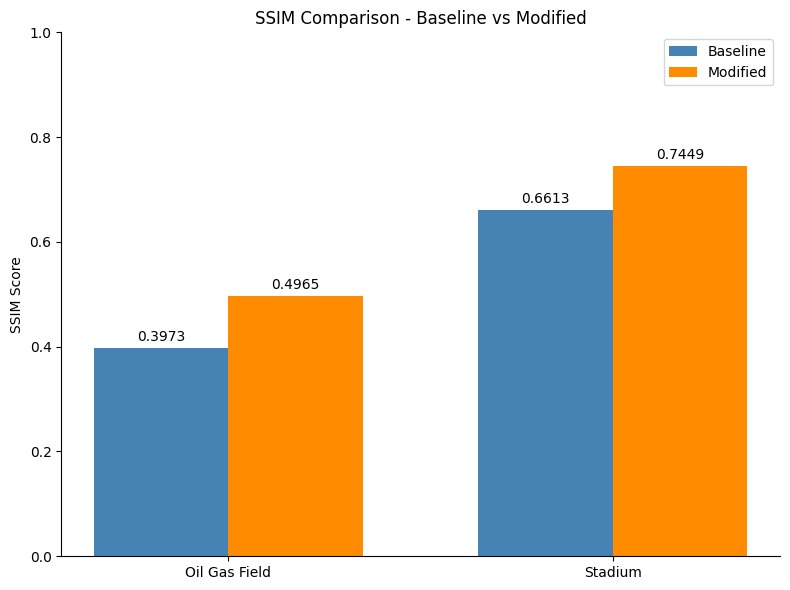

In [45]:
categories = ['Oil Gas Field', 'Stadium']
baseline_scores = [ssim_ogf, ssim_std]
modified_scores = [ssim_ogf_mod, ssim_std_mod]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue')
bars2 = ax.bar(x + width/2, modified_scores, width, label='Modified', color='darkorange')

# Tampilin nilai di atas bar
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)

ax.set_ylabel('SSIM Score')
ax.set_title('SSIM Comparison - Baseline vs Modified')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.0)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Kesimpulan

Model modified berhasil meningkatkan SSIM pada kedua kelas dibanding baseline, dengan Oil Gas Field naik dari  0.3973 menjadi 0.4965 dan Stadium naik dari  0.6613 menjadi 0.7449. Peningkatan ini membuktikan bahwa kombinasi BatchNormalization, learning rate yang lebih kecil, dan custom SSIM+MSE loss memberikan representasi dimension reduction yang lebih optimal dibanding baseline yang hanya menggunakan pure MSE.
Stadium secara konsisten mendapat SSIM lebih tinggi dari Oil Gas Field di kedua model, yang sesuai dengan karakteristik datanya. Gambar Stadium memiliki pola yang lebih seragam dan standar deviasi piksel lebih rendah sehingga lebih mudah dikompresi ke 128 dimensi tanpa kehilangan banyak informasi struktural.

1. Model baseline Oil Gas Field mendapat SSIM  0.3973, nilai ini tergolong rendah karena SSIM di bawah 0.5 menunjukkan rekonstruksi yang belum cukup baik secara struktural.

2. Tekstur Oil Gas Field sangat kompleks dan variatif, terbukti dari distribusi piksel yang bimodal dan standar deviasi yang tinggi (53.91), sehingga informasinya sulit dikompresi secara optimal ke representasi 128 dimensi tanpa kehilangan detail penting.

3. Mild overfitting terlihat dari val loss yang plateau lebih awal dibanding train loss, menandakan model mulai menghafal data training dan kurang generalisasi ke test set.

### Key Point

- Model modified lebih unggul dari baseline pada kedua kelas, membuktikan bahwa optimasi SSIM secara langsung pada loss function memberikan rekonstruksi yang lebih baik secara struktural.
- Oil Gas Field menjadi kelas yang paling challenging karena teksturnya kompleks dan variatif, terbukti dari SSIM yang lebih rendah dibanding Stadium di kedua model.
- Meski terdapat overfitting pada model modified akibat perbedaan skala loss, val loss tetap turun dan tidak naik sehingga model masih mampu generalisasi dengan baik ke test set.
- Stadium modified mencapai SSIM 0.7449 yang tergolong baik, menunjukkan model sudah mampu merepresentasikan struktur visual gambar dengan cukup akurat dalam 128 dimensi.


### Apakah model ini layak digunakan di real life?

Model ini belum sepenuhnya layak digunakan secara langsung di aplikasi nyata. Stadium dengan SSIM 0.7449 cukup menjanjikan untuk digunakan sebagai tahap awal dimension reduction, misalnya sebagai feature extractor sebelum proses klasifikasi objek satelit. Namun Oil Gas Field dengan SSIM 0.4965 masih terlalu rendah untuk aplikasi yang membutuhkan presisi tinggi seperti monitoring infrastruktur minyak dan gas dari citra satelit, karena detail struktural yang hilang dalam proses rekonstruksi bisa menyebabkan informasi kritis tidak terdeteksi.

### Future Reccomendation


- Tambah jumlah data training terutama untuk Oil Gas Field yang hanya sekitar 800 gambar, karena dataset yang lebih besar dapat membantu model belajar tekstur yang lebih beragam tanpa overfitting.
- Eksplorasi nilai alpha yang lebih granular melalui grid search yang lebih rapat, karena pemilihan alpha yang tepat terbukti berpengaruh signifikan terhadap kualitas rekonstruksi masing-masing kelas.
- Pertimbangkan augmentasi data seperti rotasi dan flipping untuk memperkaya variasi training data tanpa harus menambah data baru, mengingat gambar overhead tidak memiliki orientasi yang tetap.